# 4 — Full Pipeline Integration

Tests the integrated system with both components (Bingham filter + T³ QAN) on the 2D baseline arena (not running the experiment).

In [1]:
import os
import sys
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt


sys.path.insert(0, os.path.abspath("../.."))

from network.QAN3D import Torus3DQAN
from network.visualize3D import (
    visualize_trajectory_projections,
)
from metrics import wrapped_angle_diff
from experiments.arena_2d import Arena2DExperiment, Arena2DConfig


In [2]:
# Hyperparameters inherited from notebook 3 (path-integration tuning)
qan = Torus3DQAN(
    spacing=0.3,
    alpha=1.5,
    sigma=1.4,
    b=0.83,
    velocity_gains=65,
)
print(f"QAN ready — {len(qan.cans)} CANs, {qan.cans[0].S.shape[0]} neurons each")


QAN ready — 6 CANs, 9261 neurons each


## Set up the arena

In [3]:
g_vec = np.array([0.0, 0.0, -9.81])

cfg = Arena2DConfig(
    env_size=2.0,
    n_steps=10000,
    seed=0,
    kappa=10.0,
    alpha=0.999,
)

exp = Arena2DExperiment(qan=qan, config=cfg, record=True)
world_pos, v_body_seq, torus_gt = exp.generate_trajectory()

In [4]:
print("Running ...")
t0     = time.time()
result = exp.run_experiment(g=g_vec)

# Unpack result fields
theta_hist = result.theta_hist
gap        = result.gap_hist
n_hat_hist = result.n_hat_hist
T          = cfg.n_steps
err        = np.linalg.norm(wrapped_angle_diff(theta_hist, torus_gt), axis=1)

# Core diagnostics (1-indexed timestep labels, 0-indexed array access)
print(f"Filter gap  t=100: {gap[99]:.4f}  t=500: {gap[499]:.4f}  t={T}: {gap[-1]:.4f}  target > 2 by t=500")
print(f"nn_hat at t={T}:        {n_hat_hist[-1]}  (target [0, 0, 1])")
print(f"theta_3 decoded range:  [{theta_hist[:, 2].min():.4f}, {theta_hist[:, 2].max():.4f}]  target around [0, 0]")
print(f"MADE error  full:  {result.mean_norm_error:.4f}  after t=200: {result.norm_error[200:].mean():.4f}")


Running ...
Filter gap  t=100: 506.7748  t=500: 297.4889  t=10000: 2288.0965  target > 2 by t=500
nn_hat at t=10000:        [0. 0. 1.]  (target [0, 0, 1])
theta_3 decoded range:  [6.2832, 6.2832]  target around [0, 0]
MADE error  full:  0.0269  after t=200: 0.0247


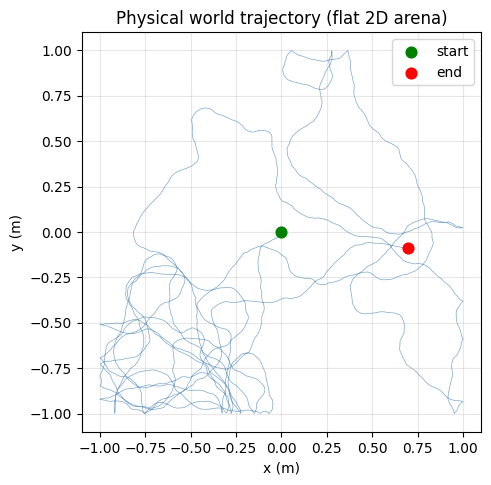

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(world_pos[:, 0], world_pos[:, 1], lw=0.5, alpha=0.7, color="steelblue")
ax.scatter(*world_pos[0, :2],  color="green", s=60, zorder=5, label="start")
ax.scatter(*world_pos[-1, :2], color="red",   s=60, zorder=5, label="end")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Physical world trajectory (flat 2D arena)")
ax.set_aspect("equal")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


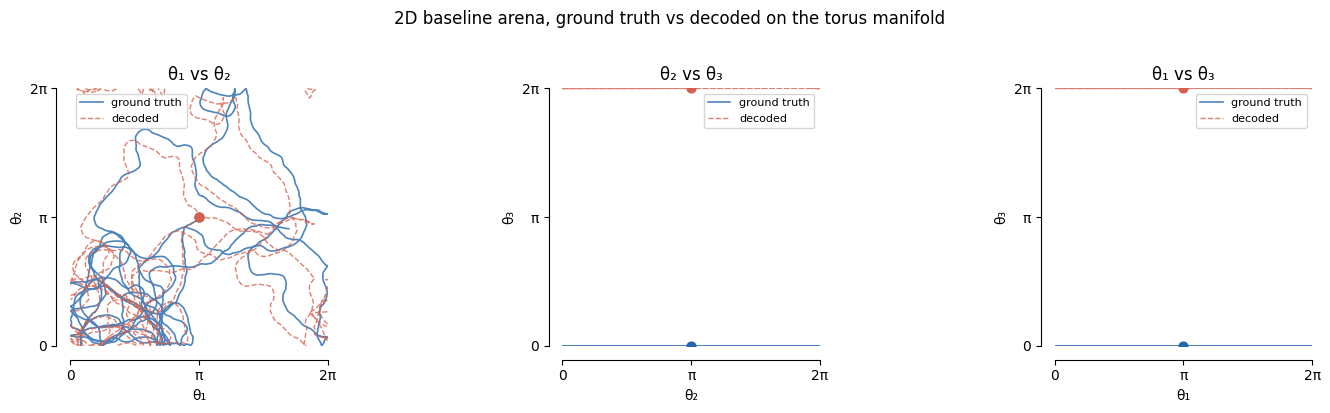

In [6]:
fig, _ = visualize_trajectory_projections(
    torus_gt, theta_hist,
    title="2D baseline arena, ground truth vs decoded on the torus manifold",
)
plt.show()
